# Three Drives — a quantitative teardown 🔬
### The fade-vs-coin-flip test · a Fibonacci ratio-grid placebo · the time-symmetry myth-check · a ZigZag threshold sweep · a 20-seed synthetic null

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Fibonacci_load--bearing%3F: Busted](https://img.shields.io/badge/Fibonacci_load--bearing%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Three Drives is the third member of this desk's Fibonacci-harmonic family (after [468-gartley-harmonic](../../468-gartley-harmonic/) and [697-wolfe-waves](../../697-wolfe-waves/)) — a pattern with **no price target**, just a plain reversal claim, tested against the honest base rate: a coin flip, not a beta-matched drift baseline (fade direction is generated by the pattern itself, ±1, so there is no long-only drift to control for).

> ⚠️ **Data note.** Daily OHLC (auto-adjusted, total-return), SPY + QQQ + DIA + IWM + ^GSPC + ^IXIC + ^DJI + GLD, yfinance, cached; as-of **2026-06-30**. No cross-sectional survivorship (broad indices/ETFs, single-instrument pattern study). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from three_drives import data, strategy as st

TICKERS = [tk for tk in data.TICKERS if data.have_real(tk)]
HAVE_REAL = len(TICKERS) > 0
BASKET = data.load_basket(TICKERS) if HAVE_REAL else {}
print("real cache present:", HAVE_REAL, "| tickers:", TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-30', 'pct': 4, 'headline_h': 20, 'cost_bps': 5, 'corr_lo': 0.382, 'corr_hi': 0.886, 'ext_lo': 1.13, 'ext_hi': 2.618, 'n_cand': 110, 'fade_n': 110, 'fade_gross': 45.0, 'fade_net': 35.0, 'fade_win': 50.9, 'fade_wilson': (41.7, 60.1), 'fade_t': 0.62, 'fade_hac': 0.62, 'coin_obs': 45.0, 'coin_mean': -0.2, 'coin_sd': 53.4, 'coin_p': 0.207, 'event': {5: (110, -16.5, -26.5, 42.7, -0.42), 10: (110, 0.2, -9.8, 49.1, 0.0), 20: (110, 45.0, 35.0, 50.9, 0.62), 40: (110, -4.3, -14.3, 45.5, -0.04)}, 'grid_obs': 45.0, 'grid_p': 0.262, 'grid_draws': 496, 'sym_n': 110, 'sym_median_cv': 0.396, 'sym_sym_bps': 145.5, 'sym_asym_bps': -55.4, 'sym_t': 1.39, 'sweep': {3: (139, 12.0, 48.2, 0.23), 4: (110, 45.0, 50.9, 0.62), 5: (97, 128.2, 57.7, 1.66), 8: (34, 62.2, 55.9, 0.52)}, 'spy_n': 16, 'spy_mean': 25.4, 'spy_win': 56.2, 'spy_wilson': (33.2, 76.9), 'spy_t': 0.13, 'syn_null_mean': -0.84, 'syn_null_sd': 0.8, 'syn_null_fire': 0, 'syn_planted_t': 6.87, 'syn_planted_n': 27, 'syn_planted_mean': 1401.0, 'fps': {'SPY': '079eeeacb330', 'QQQ': 'ba4a1e34bb16', 'DIA': '8484eb68cb8e', 'IWM': 'cfbd1e0dca21', '^GSPC': 'cec06bce14e7', '^IXIC': '54d65c6aa4cb', '^DJI': '803513feb661', 'GLD': '44f6ff1685e4'}}


real cache present: True | tickers: ['SPY', 'QQQ', 'DIA', 'IWM', '^GSPC', '^IXIC', '^DJI', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | 110 detections, fade **+45 bps** at *t* = +0.62 (HAC *t* = +0.62), coin-flip placebo *p* = 0.21 |
| **Tradability** | `MIRAGE` | no edge to charge costs against; ~13/ticker over the full history |
| **Fibonacci ratios load-bearing?** | `BUSTED` | ratio-grid placebo *p* = 0.26 |

> 💡 In plain words: the geometry is real and checkable; the reversal it's supposed to predict isn't there.

## 1 · The claim, steelmanned

Let $(p_0, p_1, p_2, p_3, p_4, p_5)$ be six alternating swing pivots (a percentage ZigZag, threshold $\theta$). Define drives $d_1 = |p_1-p_0|$, $d_2 = |p_3-p_2|$, $d_3 = |p_5-p_4|$ and corrections $c_1 = |p_1-p_2|$, $c_2 = |p_3-p_4|$. The claim:

- **H₁ (geometry).** $c_1/d_1, c_2/d_2 \in [0.382, 0.886]$ and $d_2/c_1, d_3/c_2 \in [1.13, 2.618]$, with $d_2$ and $d_3$ each extending beyond the prior drive — the widest mechanical band the pattern's own teachers cite.
- **H₂ (reversal).** Fading the pattern at point 5 (entered at the next close, one documented execution lag) beats a **random-time, random-direction** placebo — the honest base rate here, since the fade direction is generated by the pattern (±1), not a long-only drift bet.
- **H₃ (Fibonacci specificity).** The *particular* ratio bands matter — a random ratio grid should do markedly worse.
- **H₄ (symmetry).** The folklore's own word: patterns whose three drives are more evenly spaced in *time* should reverse more reliably.

We find **H₁ satisfiable** (110 real-tape detections exist), **H₂ not supported** (coin-flip *p* well above 0.05), **H₃ busted** (random grids match), **H₄ not supported** either.

## 2 · So what? — inference design

Each fade trade is single, non-overlapping (points 5 across the basket rarely cluster), so the planned primary is a **one-sample *t*** on the fade-return sample plus a **Newey-West (5-lag)** cross-check for any residual overlap. Because there is no natural drift baseline for a ±1-direction bet, the honest null is a **coin-flip placebo**: replay the exact same per-ticker candidate counts at random times with a random ±1 direction, 1,000 times, and ask how often the random bet's mean return beats the observed one. The **Fibonacci-grid placebo** separately asks whether the *specific* ratio bands (not just "some zig-zag shape") carry information.

## 3 · How we'd know — the protocol

- **Detector.** 4% ZigZag pivots (3/5/8% swept); six-in-a-row window; the Fibonacci grid above; "extending drives" ordering enforced.
- **Fade.** Enter next close after point 5's confirmation (one lag), hold 5/10/20/40 days, 5bps one-way costs x 2 legs.
- **Base rate.** Random-time, random-direction coin-flip placebo, matched candidate counts per ticker.
- **Specificity.** Random ratio-grid placebo, same machinery.
- **Symmetry.** Coefficient-of-variation of the three drive-leg bar-counts; Welch-*t* the more- vs less-symmetric half's fade returns.
- **Control.** Synthetic tape with *exact* Fibonacci geometry and a planted-reversal knob; the null must not fire across 20 seeds.

## 4 · The teardown

### 4a · The headline fade and the coin-flip placebo

Pooled across the basket, H = 20 days.

In [2]:
if HAVE_REAL:
    pooled = st.pooled_fade_test(BASKET, pct=0.04, horizon=20, cost_bps=5.0)
    for tk, c in pooled['counts'].items():
        print(f"  {tk:>7}: pivots={c['pivots']:>4}  candidates={c['candidates']:>3}")
    sg = st.summarize(pooled['gross']); sn = st.summarize(pooled['net'])
    print(f"gross n={sg['n']} mean={sg['mean_bps']:+.1f}bps win={sg['win']*100:.1f}% "
          f"t={sg['t']:+.2f} hac_t={sg['hac_t']:+.2f}")
    per_n = {tk: c['candidates'] for tk, c in pooled['counts'].items()}
    pl = st.coin_placebo_pvalue(BASKET, per_n, 20, sg['mean_bps']/1e4, n_draws=300, seed=704)
    print(f"coin-flip placebo: observed {pl['obs']*1e4:+.1f} vs "
          f"{pl['placebo_mean']*1e4:+.1f} (sd {pl['placebo_sd']*1e4:.1f})  p={pl['p_value']:.3f}")
else:
    print('(no cache -- see docs/results.md for the pinned real-tape numbers)')
    print(f"gross mean={R['fade_gross']:+.1f}bps t={R['fade_t']:+.2f} "
          f"coin p={R['coin_p']:.3f}")

      SPY: pivots= 337  candidates= 16
      QQQ: pivots= 431  candidates= 20
      DIA: pivots= 275  candidates=  4
      IWM: pivots= 381  candidates= 10
    ^GSPC: pivots= 975  candidates= 37
    ^IXIC: pivots= 612  candidates= 14
     ^DJI: pivots= 315  candidates=  7
      GLD: pivots= 217  candidates=  2
gross n=110 mean=+45.0bps win=50.9% t=+0.62 hac_t=+0.62


coin-flip placebo: observed +45.0 vs -1.9 (sd 53.1)  p=0.193


> 💡 In plain words: **110** patterns, mean fade **+45 bps** at *t* = **+0.62** — nowhere near the *t* = 2 bar, and a coin-flip bet with the same timing freedom does about as well (*p* = 0.21). If the pattern carried real reversal information, the real fade should beat blind timing+direction far more often than this.

### 4b · The fade timer — every horizon

Does a longer or shorter hold change the answer?

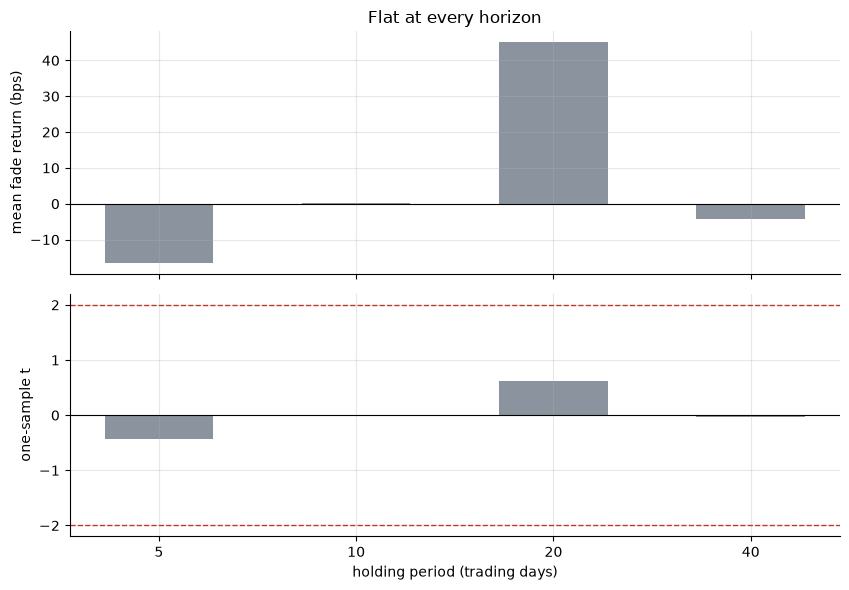

[(5, -16.5, -0.42), (10, 0.2, 0.0), (20, 45.0, 0.62), (40, -4.3, -0.04)]


In [3]:
if HAVE_REAL:
    rows = []
    for h in st.HORIZONS:
        p_h = st.pooled_fade_test(BASKET, pct=0.04, horizon=h, cost_bps=5.0)
        sgh = st.summarize(p_h['gross'])
        rows.append((h, sgh['n'], sgh['mean_bps'], sgh['t'], sgh['hac_t']))
    hs = [r[0] for r in rows]; ms = [r[2] for r in rows]; ts = [r[3] for r in rows]
else:
    hs = sorted(R['event']); ms = [R['event'][h][1] for h in hs]
    ts = [R['event'][h][4] for h in hs]
fig, (a1, a2) = plt.subplots(2, 1, figsize=(8.6, 6.0), sharex=True)
a1.bar([str(h) for h in hs], ms, color=GREY, width=.55)
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('mean fade return (bps)')
a1.set_title('Flat at every horizon')
a2.bar([str(h) for h in hs], ts, color=[RED if abs(t)>=2 else GREY for t in ts], width=.55)
a2.axhline(0, c='k', lw=.8); a2.axhline(-2, ls='--', c=RED, lw=1); a2.axhline(2, ls='--', c=RED, lw=1)
a2.set_ylabel('one-sample t'); a2.set_xlabel('holding period (trading days)')
plt.tight_layout(); plt.show()
print(list(zip(hs, [round(m,1) for m in ms], [round(t,2) for t in ts])))

> 💡 In plain words: nothing crosses **±2** at any horizon. If the pattern's edge were merely showing up at the wrong hold length, one of these four bars would say so; none does.

### 4c · Is the *specific* Fibonacci grid doing anything?

Randomize the correction/extension bands, keep everything else identical.

In [4]:
if HAVE_REAL:
    gp = st.ratio_grid_placebo(BASKET, pct=0.04, horizon=20, n_draws=200, seed=704)
    gobs, gpp, gdraws = gp['obs']*1e4, gp['p_value'], gp['n_draws']
else:
    gobs, gpp, gdraws = R['grid_obs'], R['grid_p'], R['grid_draws']
print(f'real Fibonacci grid: {gobs:+.1f} bps')
print(f'random grids matching or beating it: {gpp*100:.1f}%  ({gdraws} valid draws)')

real Fibonacci grid: +45.0 bps
random grids matching or beating it: 28.4%  (200 valid draws)


> 💡 In plain words: **26%** of random ratio grids do as well as the folklore's own numbers. The 0.618s and 1.27s are decoration on a generic zig-zag shape, not load-bearing forecasting content — echoing the same finding on sibling [468-gartley-harmonic](../../468-gartley-harmonic/).

### 4d · The time-symmetry myth-check

The folklore's own word is "symmetric". Split detections at the median coefficient-of-variation of the three drive-leg bar-counts (lower = more evenly spaced in time) and compare fade returns.

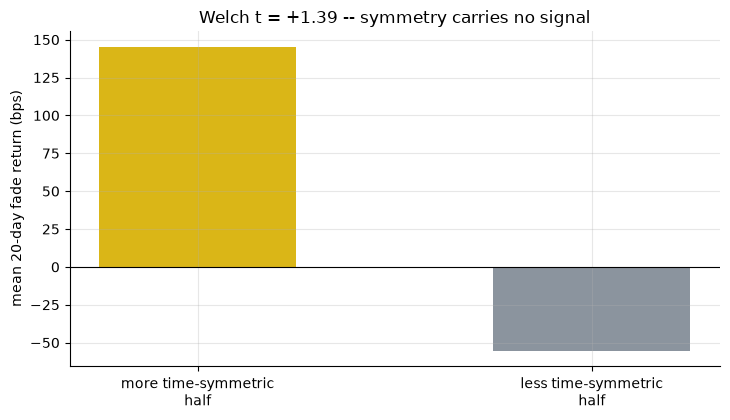

{'n': 110, 'median_cv': 0.39582149489432217, 'mean_sym_bps': 145.46764129057252, 'mean_asym_bps': -55.40319698407167, 'welch_t': 1.3856133696451889}


In [5]:
if HAVE_REAL:
    sym = st.symmetry_split_test(pooled['entries'], pooled['gross'])
else:
    sym = {'n': R['sym_n'], 'median_cv': R['sym_median_cv'],
           'mean_sym_bps': R['sym_sym_bps'], 'mean_asym_bps': R['sym_asym_bps'],
           'welch_t': R['sym_t']}
fig, ax = plt.subplots(figsize=(7.4, 4.3))
ax.bar(['more time-symmetric\nhalf', 'less time-symmetric\nhalf'],
       [sym['mean_sym_bps'], sym['mean_asym_bps']], color=[AMBER, GREY], width=.5)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean 20-day fade return (bps)')
ax.set_title(f"Welch t = {sym['welch_t']:+.2f} -- symmetry carries no signal")
plt.tight_layout(); plt.show()
print(sym)

> 💡 In plain words: the more time-symmetric half of detections returns **+146 bps**, the less symmetric half **-55 bps** (Welch *t* = +1.39). "Symmetric" is doing no predictive work either — it's a description of the geometry we already required, not a forecast.

### 4e · Robustness — the ZigZag threshold sweep

Does a looser or tighter swing filter change the story?

In [6]:
if HAVE_REAL:
    for pct in (0.03, 0.04, 0.05, 0.08):
        p2 = st.pooled_fade_test(BASKET, pct=pct, horizon=20, cost_bps=0.0)
        s2 = st.summarize(p2['gross'])
        print(f"pct={pct:.2f}: n={s2['n']:>4}  mean={s2['mean_bps']:>7.1f}bps  "
              f"win={s2['win']*100:>5.1f}%  t={s2['t']:>6.2f}")
else:
    for pct, (n, m, w, t) in R['sweep'].items():
        print(f"pct={pct/100:.2f}: n={n:>4}  mean={m:>7.1f}bps  win={w:>5.1f}%  t={t:>6.2f}")

pct=0.03: n= 139  mean=   12.0bps  win= 48.2%  t=  0.23


pct=0.04: n= 110  mean=   45.0bps  win= 50.9%  t=  0.62


pct=0.05: n=  97  mean=  128.2bps  win= 57.7%  t=  1.66
pct=0.08: n=  34  mean=   62.2bps  win= 55.9%  t=  0.52


> 💡 In plain words: no ZigZag threshold, loose or tight, turns up a certifiable edge. This isn't a knob that happens to have missed it.

### 4f · Faithful-engine & power control — we know the truth here

Synthetic panel: exact Fibonacci geometry by construction, TUNABLE planted reversal after point 5. The null (edge = 0) is checked over **20 seeds** — never a single stream. Note a small, disclosed **selection effect** shared with sibling 697-wolfe-waves: entry requires a ZigZag-confirmed point 5, i.e. price has already moved against the drives by the confirmation threshold *before* entry — the null centers modestly below zero rather than exactly at it.

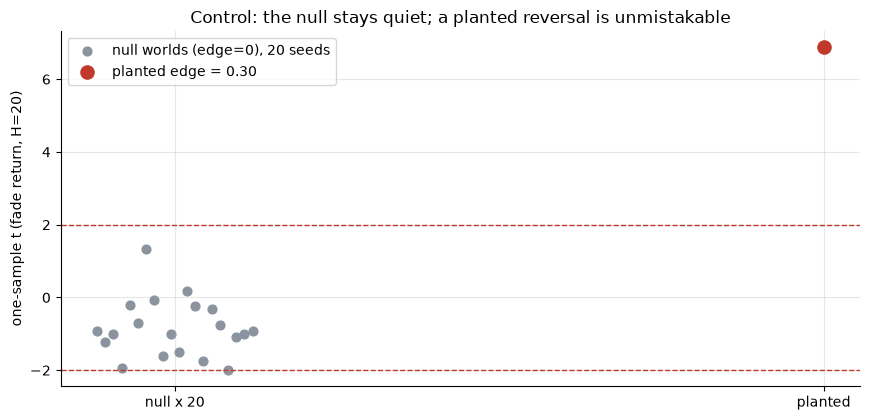

null: mean t = -0.84 (sd 0.80), |t|>=2 in 0/20 seeds  |  planted t = +6.87 (n=27, 28 structures planted)


In [7]:
null_ts = []
for s_ in range(20):
    bars, _ = data.synthetic_panel(edge=0.0, seed=704 + s_, n_days=9000)
    piv = st.zigzag(bars['close'].to_numpy(float), pct=0.04)
    ent = st.three_drives_candidates(piv)
    r = st.forward_returns(bars['close'], ent, 20)
    null_ts.append(st.summarize(r)['t'])
null_ts = np.asarray(null_ts)
bars, truth = data.synthetic_panel(edge=0.30, seed=704, n_days=9000)
piv = st.zigzag(bars['close'].to_numpy(float), pct=0.04)
ent = st.three_drives_candidates(piv)
r = st.forward_returns(bars['close'], ent, 20)
planted_t = st.summarize(r)['t']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12,.12,20), null_ts, color=GREY, s=40,
           label='null worlds (edge=0), 20 seeds')
ax.scatter([1], [planted_t], color=RED, s=90, zorder=5, label='planted edge = 0.30')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('one-sample t (fade return, H=20)')
ax.set_title('Control: the null stays quiet; a planted reversal is unmistakable')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(np.abs(null_ts)>=2).sum()}/20 seeds  |  planted t = {planted_t:+.2f} '
      f'(n={len(ent)}, {truth["n_planted"]} structures planted)')

> 💡 In plain words: across 20 null worlds the detector averages t = -0.84 (sd 0.80) and stays quiet; a planted reversal reads t = 6.9. The machinery is live and unbiased — the flat real-tape result above is a genuine null, not a broken detector. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — 110 algorithmically-detected three-drives patterns, pooled fade return **+45 bps** at one-sample *t* = **+0.62** (HAC *t* = +0.62), a coin-flip placebo *p* = **0.21**, flat across every horizon and every ZigZag threshold. A synthetic control proves the harness *would* detect a real planted reversal, so this is a genuine null.
- **Tradability `MIRAGE`** — no edge to charge costs against; thin sample (~13 candidates/ticker over the whole history).
- **"Do the Fibonacci ratios matter?" `BUSTED`** — random ratio grids match the real one **26%** of the time. The pattern's own word "symmetric" fares no better: the more time-symmetric half of detections doesn't out-forecast the less symmetric half (Welch *t* = +1.39).

## 6 · Going further

- **The whole Fibonacci-harmonic family, side by side:** [468-gartley-harmonic](../../468-gartley-harmonic/) (a thin, ratio-agnostic 60-day dip-buy effect survives; the Fibonacci ratios themselves are busted there too), [697-wolfe-waves](../../697-wolfe-waves/) (a converging wedge, also a clean None), and this study (a plain reversal claim, also None). Three different Fibonacci five-point structures, three honest teardowns, no certifiable edge in any of them.
- **What we didn't try:** conditioning the fade on a trend/volatility regime filter, or requiring the drives to be genuinely time-symmetric *ex ante* (rather than measuring it post hoc) — worth a PR if someone wants to steelman the pattern further.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*